In [1]:
import pandas as pd

# Usando o caminho padrão do Colab (verifique se os nomes dos seus arquivos estão exatamente assim)
df_details = pd.read_csv('/content/Details_Itapema.csv')
df_hosts = pd.read_csv('/content/Hosts_ids_Itapema.csv')
df_mesh = pd.read_csv('/content/Mesh_Ids_Data_Itapema.csv')
df_price = pd.read_csv('/content/Price_AV_Itapema.csv')
df_vivareal = pd.read_csv('/content/VivaReal_Itapema.csv')

print("--- Details_Itapema ---")
print(df_details.head(3))
print("\n--- Price_AV_Itapema ---")
print(df_price.head(3))
print("\n--- VivaReal_Itapema ---")
print(df_vivareal.head(3))

--- Details_Itapema ---
     airbnb_listing_id                                                url  \
0  1018938592594574382  https://www.airbnb.com.br/rooms/10189385925945...   
1   991407580891691701  https://www.airbnb.com.br/rooms/99140758089169...   
2             41074064           https://www.airbnb.com.br/rooms/41074064   

                                           ad_name  \
0                    Apartamento em centro itapema   
1  Apto em otima localização em Meia Praia EIO6031   
2           Paraíso do lazer, descanso e segurança   

                                      ad_description  \
0  Aconchegante, bem iluminado, poucos metros do ...   
1  Este espaçoso apto é perfeito para família ou ...   
2  Linda e aconchegante casa em condomínio fechad...   

                                               space  \
0                                                NaN   
1  <br />Para o conforto de nossos hóspedes, o im...   
2  <br />O hóspede pode usar todas as áreas do co...   



In [2]:
# 1. Verificando as chaves exatas de conexão
print("--- Colunas de Mesh e Hosts ---")
print("Mesh:", df_mesh.columns.tolist())
print("Hosts:", df_hosts.columns.tolist())

# 2. Agregando a Receita do Airbnb (Price_AV)
# Calculando o Preço Médio (ADR) e a quantidade de dias mapeados por anúncio
df_receita = df_price.groupby('airbnb_listing_id').agg(
    preco_medio=('price', 'mean'),
    dias_mapeados=('date', 'count')
).reset_index()

print("\n--- Amostra da Receita Airbnb Agregada ---")
print(df_receita.head())

# 3. Analisando o VivaReal (Custos de Compra)
# Garantindo que os dados de preço são numéricos e filtrando apenas "Venda"
df_vivareal['sale_price'] = pd.to_numeric(df_vivareal['sale_price'], errors='coerce')
df_vr_venda = df_vivareal[df_vivareal['business_types'] == 'Venda'].copy()

# Calculando a mediana de preço de compra por bairro e número de quartos
custo_por_bairro_quarto = df_vr_venda.groupby(['suburb', 'bedrooms'])['sale_price'].median().reset_index()

print("\n--- Mediana de Preço de Venda (VivaReal) por Bairro e Quartos ---")
print(custo_por_bairro_quarto.head(10))

--- Colunas de Mesh e Hosts ---
Mesh: ['airbnb_listing_id', 'latitude', 'longitude', 'suburb', 'country', 'state', 'city', 'aquisition_date']
Hosts: ['owner_id', 'owner', 'is_superhost', 'number_of_reviews_host', 'is_verified', 'star_rating_host', 'years_host', 'months_host', 'response_rate_shown', 'response_time_shown', 'host_snapshot_date']

--- Amostra da Receita Airbnb Agregada ---
   airbnb_listing_id  preco_medio  dias_mapeados
0            1977915   864.380504            159
1            2951220   789.667647             85
2            3263701  1533.333333             48
3            3977675   242.712121             55
4            5443557   799.115854             82

--- Mediana de Preço de Venda (VivaReal) por Bairro e Quartos ---
           suburb  bedrooms  sale_price
0  Alto São Bento         0    651000.0
1  Alto São Bento         2    618710.0
2  Alto São Bento         3    690000.0
3  Alto São Bento         6   1000000.0
4       Andorinha         0   2900000.0
5       An

In [3]:
# 1. Diagnóstico de Nulos
print("--- Valores Nulos por Tabela ---")
print("Details (Quartos Nulos):", df_details['number_of_bedrooms'].isna().sum())
print("VivaReal (Preço Nulo):", df_vivareal['sale_price'].isna().sum())
print("VivaReal (Quartos Nulos):", df_vivareal['bedrooms'].isna().sum())

# 2. Perfil Estatístico (Buscando Outliers)
# Convertendo preço do VivaReal e Airbnb para numérico temporariamente para análise
df_price['price_num'] = pd.to_numeric(df_price['price'], errors='coerce')
df_vivareal['sale_price_num'] = pd.to_numeric(df_vivareal['sale_price'], errors='coerce')

print("\n--- Estatísticas do Airbnb (Diárias) ---")
# Formatando para evitar notação científica e facilitar a leitura
print(df_price['price_num'].describe().apply(lambda x: format(x, '.2f')))

print("\n--- Estatísticas do VivaReal (Preço de Venda) ---")
print(df_vivareal['sale_price_num'].describe().apply(lambda x: format(x, '.2f')))

--- Valores Nulos por Tabela ---
Details (Quartos Nulos): 0
VivaReal (Preço Nulo): 0
VivaReal (Quartos Nulos): 0

--- Estatísticas do Airbnb (Diárias) ---
count    118839.00
mean        713.10
std         499.70
min          63.00
25%         450.00
50%         607.00
75%         842.00
max       29000.00
Name: price_num, dtype: object

--- Estatísticas do VivaReal (Preço de Venda) ---
count        8329.00
mean      2450770.28
std       2480208.64
min         10000.00
25%        900000.00
50%       1750000.00
75%       2890000.00
max      44000000.00
Name: sale_price_num, dtype: object


In [5]:
import pandas as pd

# 1. Receita Airbnb: Diária mediana por anúncio (isolando outliers internos)
df_receita = df_price.groupby('airbnb_listing_id').agg(
    diaria_mediana_imovel=('price', 'median'),
    dias_raspados=('date', 'nunique')
).reset_index()

# 2. Unindo Airbnb (Detalhes + Bairro + Receita)
df_airbnb = df_details.merge(df_mesh[['airbnb_listing_id', 'suburb']], on='airbnb_listing_id', how='inner')
df_airbnb = df_airbnb.merge(df_receita, on='airbnb_listing_id', how='inner')

# Agrupando a Receita do Airbnb por Bairro e Quartos (Mediana do cluster)
df_receita_cluster = df_airbnb.groupby(['suburb', 'number_of_bedrooms']).agg(
    diaria_mediana_bairro=('diaria_mediana_imovel', 'median'),
    volume_anuncios=('airbnb_listing_id', 'count')
).reset_index()
df_receita_cluster.rename(columns={'number_of_bedrooms': 'bedrooms'}, inplace=True)

# 3. Tratamento do VivaReal (Custo de Aquisição)
df_vr_venda = df_vivareal[df_vivareal['business_types'] == 'Venda'].copy()
df_custo = df_vr_venda.groupby(['suburb', 'bedrooms'])['sale_price'].median().reset_index()

# 4. Cruzamento Final e Modelagem de Cenários (Gross Yield)
df_roi = df_receita_cluster.merge(df_custo, on=['suburb', 'bedrooms'], how='inner')

# Projetando receita anual baseada em cenários de ocupação
df_roi['receita_ano_40_ocup'] = df_roi['diaria_mediana_bairro'] * (365 * 0.40)
df_roi['receita_ano_70_ocup'] = df_roi['diaria_mediana_bairro'] * (365 * 0.70)

# Calculando ROI Anual (%)
df_roi['roi_40%'] = (df_roi['receita_ano_40_ocup'] / df_roi['sale_price']) * 100
df_roi['roi_70%'] = (df_roi['receita_ano_70_ocup'] / df_roi['sale_price']) * 100

# Filtrando clusters com menos de 5 anúncios para evitar anomalias estatísticas
df_roi = df_roi[df_roi['volume_anuncios'] > 5]
df_roi = df_roi.sort_values(by='roi_70%', ascending=False).round(2)

print("--- TOP 5 PERFIS DE ALTA RENTABILIDADE ---")
print(df_roi[['suburb', 'bedrooms', 'diaria_mediana_bairro', 'sale_price', 'roi_40%', 'roi_70%']].head(5))

print("\n--- TESTE DE ESTRESSE: STUDIOS NO CENTRO (Tese Seazone) ---")
tese_centro = df_roi[(df_roi['suburb'] == 'Centro') & (df_roi['bedrooms'] <= 1)]
if not tese_centro.empty:
    print(tese_centro[['suburb', 'bedrooms', 'diaria_mediana_bairro', 'sale_price', 'roi_40%', 'roi_70%']])
else:
    print("Sem dados suficientes na amostra para Studios no Centro.")

--- TOP 5 PERFIS DE ALTA RENTABILIDADE ---
                     suburb  bedrooms  diaria_mediana_bairro  sale_price  \
24                 Morretes         3                 620.00    790000.0   
23                 Morretes         2                 457.50    750000.0   
27  Tabuleiro dos Oliveiras         2                 440.88    782900.0   
22                 Morretes         1                 350.00    649000.0   
4               Casa Branca         2                 350.00    676450.0   

    roi_40%  roi_70%  
24    11.46    20.05  
23     8.91    15.59  
27     8.22    14.39  
22     7.87    13.78  
4      7.55    13.22  

--- TESTE DE ESTRESSE: STUDIOS NO CENTRO (Tese Seazone) ---
   suburb  bedrooms  diaria_mediana_bairro  sale_price  roi_40%  roi_70%
6  Centro         1                  433.5    890000.0     7.11    12.44


In [6]:
# O DataFrame df_roi já está na memória da execução anterior

# 1. Ajuste de Quartos para o cálculo (Studios com 0 quartos precisam contar como 1 ambiente físico)
df_roi['quartos_ajustados'] = df_roi['bedrooms'].apply(lambda x: 1 if x == 0 else x)

# 2. CONTRAPROVA 1: Eficiência por Quarto (RevPAR)
# Quanto cada quarto gera de receita individualmente?
df_roi['diaria_por_quarto'] = df_roi['diaria_mediana_bairro'] / df_roi['quartos_ajustados']
df_eficiencia = df_roi.sort_values(by='diaria_por_quarto', ascending=False).round(2)

print("--- CONTRAPROVA 1: EFICIÊNCIA DO METRO QUADRADO (Diária por Quarto) ---")
print(df_eficiencia[['suburb', 'bedrooms', 'diaria_mediana_bairro', 'diaria_por_quarto', 'roi_70%']].head(5))

# 3. CONTRAPROVA 2: Escalabilidade e Liquidez (Volume de Mercado)
# Onde está a verdadeira massa de dados da cidade?
df_volume = df_roi.sort_values(by='volume_anuncios', ascending=False)

print("\n--- CONTRAPROVA 2: ESCALABILIDADE (Volume de Anúncios no Airbnb) ---")
print(df_volume[['suburb', 'bedrooms', 'volume_anuncios', 'roi_70%']].head(5))

--- CONTRAPROVA 1: EFICIÊNCIA DO METRO QUADRADO (Diária por Quarto) ---
        suburb  bedrooms  diaria_mediana_bairro  diaria_por_quarto  roi_70%
15  Meia Praia         0                  435.0              435.0     6.09
6       Centro         1                  433.5              433.5    12.44
22    Morretes         1                  350.0              350.0    13.78
16  Meia Praia         1                  330.0              330.0     9.55
7       Centro         2                  557.0              278.5    12.88

--- CONTRAPROVA 2: ESCALABILIDADE (Volume de Anúncios no Airbnb) ---
        suburb  bedrooms  volume_anuncios  roi_70%
18  Meia Praia         3              332     9.30
17  Meia Praia         2              191    10.74
6       Centro         1               82    12.44
7       Centro         2               67    12.88
19  Meia Praia         4               62     7.63


In [7]:
# 1. Preparando a base de diárias com o Mês
df_price['date'] = pd.to_datetime(df_price['date'])
df_price['mes'] = df_price['date'].dt.month

# 2. Unindo com os detalhes do Airbnb
df_sazonal = df_price.merge(df_airbnb[['airbnb_listing_id', 'suburb', 'number_of_bedrooms']], on='airbnb_listing_id', how='inner')

# 3. Filtrando os dois grandes rivais do mercado
filtro_centro = (df_sazonal['suburb'] == 'Centro') & (df_sazonal['number_of_bedrooms'] <= 1)
filtro_praia = (df_sazonal['suburb'] == 'Meia Praia') & (df_sazonal['number_of_bedrooms'] == 3)

df_rivais = df_sazonal[filtro_centro | filtro_praia].copy()
df_rivais['Perfil'] = df_rivais.apply(lambda row: 'Centro - 1 Quarto' if row['suburb'] == 'Centro' else 'Meia Praia - 3 Quartos', axis=1)

# 4. Agrupando por Mês para ver a queda de preço na Baixa Temporada
sazonalidade = df_rivais.groupby(['Perfil', 'mes'])['price'].median().unstack()

print("--- COMPORTAMENTO DA DIÁRIA MEDIANA POR MÊS (Sazonalidade) ---")
print(sazonalidade)

--- COMPORTAMENTO DA DIÁRIA MEDIANA POR MÊS (Sazonalidade) ---
mes                         1      2      3      4
Perfil                                            
Centro - 1 Quarto       579.0  550.0  450.0  419.0
Meia Praia - 3 Quartos  900.0  800.0  675.0  523.0


In [9]:
from collections import Counter
import ast

# 1. Isolando os anúncios do nosso perfil vencedor
df_vencedor = df_airbnb[(df_airbnb['suburb'] == 'Centro') & (df_airbnb['number_of_bedrooms'] <= 1)].copy()

# 2. Separando os imóveis acima da mediana de preço (Os que cobram mais caro)
# NOME CORRIGIDO AQUI:
mediana_centro = df_vencedor['diaria_mediana_imovel'].median()
df_premium = df_vencedor[df_vencedor['diaria_mediana_imovel'] > mediana_centro].copy()

# 3. Limpeza e mineração da coluna 'amenities'
todas_comodidades = []

for lista_str in df_premium['amenities'].dropna():
    try:
        # Converte a string de lista "['Wi-Fi', 'Piscina']" em uma lista real do Python
        lista_real = ast.literal_eval(lista_str)
        todas_comodidades.extend(lista_real)
    except:
        continue

# 4. Contando os itens mais frequentes nos imóveis premium
contagem = Counter(todas_comodidades)

print("--- TOP 10 COMODIDADES DOS IMÓVEIS PREMIUM (Centro - 1 Quarto) ---")
for item, freq in contagem.most_common(10):
    print(f"{item}: {freq} anúncios")

--- TOP 10 COMODIDADES DOS IMÓVEIS PREMIUM (Centro - 1 Quarto) ---
Cozinha: 38 anúncios
TV: 37 anúncios
Wi-Fi: 37 anúncios
Louças e talheres: 37 anúncios
Água quente: 36 anúncios
Ar-condicionado: 36 anúncios
Microondas: 36 anúncios
Secador de cabelo: 35 anúncios
Ferro de passar: 35 anúncios
Taças de vinho: 35 anúncios


/tmp/ipykernel_1107/4005194556.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df_grafico_roi, x='roi_70%', y='Perfil', palette='viridis')
/tmp/ipykernel_1107/4005194556.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=df_volume, x='volume_anuncios', y='Perfil', palette='magma')
/tmp/ipykernel_1107/4005194556.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], data=top_comodidades, x='Frequência', y='Comodidade', palette='Blues_r')


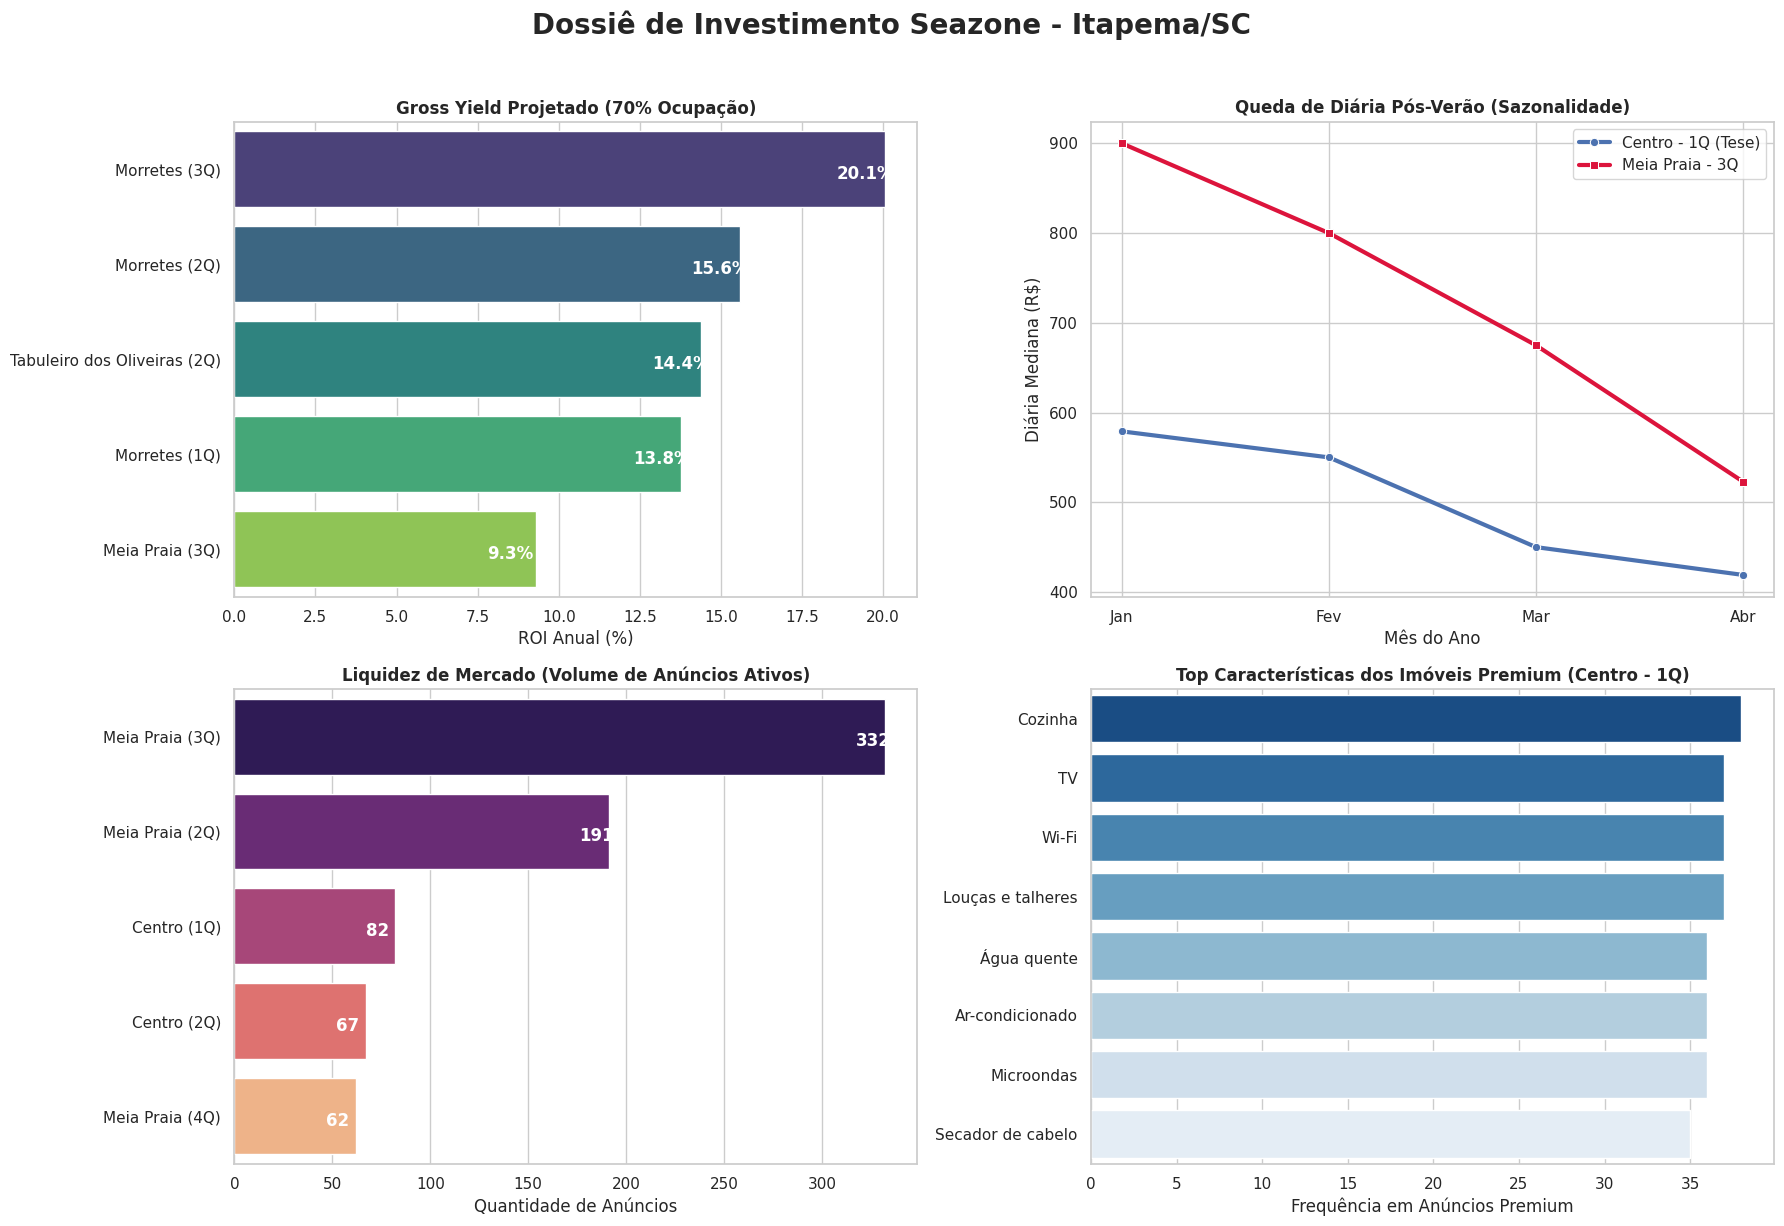

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuração global de estilo corporativo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Dossiê de Investimento Seazone - Itapema/SC', fontsize=20, fontweight='bold', y=1.02)

# --- Gráfico 1: ROI Projetado (Cenário 70%) ---
df_grafico_roi = df_roi.head(4).copy()
meia_praia = df_roi[(df_roi['suburb'] == 'Meia Praia') & (df_roi['bedrooms'] == 3)]
df_grafico_roi = pd.concat([df_grafico_roi, meia_praia])
df_grafico_roi['Perfil'] = df_grafico_roi['suburb'] + ' (' + df_grafico_roi['bedrooms'].astype(int).astype(str) + 'Q)'

sns.barplot(ax=axes[0, 0], data=df_grafico_roi, x='roi_70%', y='Perfil', palette='viridis')
axes[0, 0].set_title('Gross Yield Projetado (70% Ocupação)', fontweight='bold')
axes[0, 0].set_xlabel('ROI Anual (%)')
axes[0, 0].set_ylabel('')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_width():.1f}%', (p.get_width() - 1.5, p.get_y() + 0.5), color='white', fontweight='bold')

# --- Gráfico 2: Sazonalidade (Resiliência na Baixa Temporada) ---
sazonalidade_grafico = sazonalidade.T.reset_index()
sns.lineplot(ax=axes[0, 1], data=sazonalidade_grafico, x='mes', y='Centro - 1 Quarto', marker='o', linewidth=3, label='Centro - 1Q (Tese)')
sns.lineplot(ax=axes[0, 1], data=sazonalidade_grafico, x='mes', y='Meia Praia - 3 Quartos', marker='s', linewidth=3, label='Meia Praia - 3Q', color='crimson')
axes[0, 1].set_title('Queda de Diária Pós-Verão (Sazonalidade)', fontweight='bold')
axes[0, 1].set_xlabel('Mês do Ano')
axes[0, 1].set_ylabel('Diária Mediana (R$)')
axes[0, 1].set_xticks([1, 2, 3, 4], ['Jan', 'Fev', 'Mar', 'Abr'])

# --- Gráfico 3: Liquidez e Escala (Volume de Anúncios) ---
df_volume = df_roi.sort_values(by='volume_anuncios', ascending=False).head(5)
df_volume['Perfil'] = df_volume['suburb'] + ' (' + df_volume['bedrooms'].astype(int).astype(str) + 'Q)'
sns.barplot(ax=axes[1, 0], data=df_volume, x='volume_anuncios', y='Perfil', palette='magma')
axes[1, 0].set_title('Liquidez de Mercado (Volume de Anúncios Ativos)', fontweight='bold')
axes[1, 0].set_xlabel('Quantidade de Anúncios')
axes[1, 0].set_ylabel('')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{int(p.get_width())}', (p.get_width() - 15, p.get_y() + 0.5), color='white', fontweight='bold')

# --- Gráfico 4: Direcionadores de Receita (Comodidades) ---
# Usando a variável 'contagem' gerada no script anterior
top_comodidades = pd.DataFrame(contagem.most_common(8), columns=['Comodidade', 'Frequência'])
sns.barplot(ax=axes[1, 1], data=top_comodidades, x='Frequência', y='Comodidade', palette='Blues_r')
axes[1, 1].set_title('Top Características dos Imóveis Premium (Centro - 1Q)', fontweight='bold')
axes[1, 1].set_xlabel('Frequência em Anúncios Premium')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files

# Configuração global corporativa
sns.set_theme(style="whitegrid")

# --- 1. Gráfico de ROI ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_grafico_roi, x='roi_70%', y='Perfil', palette='viridis')
plt.title('Gross Yield Projetado (70% Ocupação)', fontweight='bold')
plt.xlabel('ROI Anual (%)')
plt.ylabel('')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_width():.1f}%', (p.get_width() - 1.5, p.get_y() + 0.5), color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('1_ROI_Projetado.png', dpi=300, bbox_inches='tight')
files.download('1_ROI_Projetado.png')
plt.close()

# --- 2. Gráfico de Sazonalidade ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=sazonalidade_grafico, x='mes', y='Centro - 1 Quarto', marker='o', linewidth=3, label='Centro - 1Q (Tese)')
sns.lineplot(data=sazonalidade_grafico, x='mes', y='Meia Praia - 3 Quartos', marker='s', linewidth=3, label='Meia Praia - 3Q', color='crimson')
plt.title('Queda de Diária Pós-Verão (Sazonalidade)', fontweight='bold')
plt.xlabel('Mês do Ano')
plt.ylabel('Diária Mediana (R$)')
plt.xticks([1, 2, 3, 4], ['Janeiro', 'Fevereiro', 'Março', 'Abril'])
plt.legend(title='Perfil do Imóvel')
plt.tight_layout()
plt.savefig('2_Sazonalidade.png', dpi=300, bbox_inches='tight')
files.download('2_Sazonalidade.png')
plt.close()

# --- 3. Gráfico de Liquidez (Volume) ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_volume, x='volume_anuncios', y='Perfil', palette='magma')
plt.title('Liquidez de Mercado (Volume de Anúncios Ativos)', fontweight='bold')
plt.xlabel('Quantidade de Anúncios')
plt.ylabel('')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_width())}', (p.get_width() - 15, p.get_y() + 0.5), color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('3_Liquidez_Mercado.png', dpi=300, bbox_inches='tight')
files.download('3_Liquidez_Mercado.png')
plt.close()

# --- 4. Gráfico de Comodidades ---
plt.figure(figsize=(10, 6))
sns.barplot(data=top_comodidades, x='Frequência', y='Comodidade', palette='Blues_r')
plt.title('Top Características dos Imóveis Premium (Centro - 1Q)', fontweight='bold')
plt.xlabel('Frequência em Anúncios Premium')
plt.ylabel('')
plt.tight_layout()
plt.savefig('4_Comodidades_Premium.png', dpi=300, bbox_inches='tight')
files.download('4_Comodidades_Premium.png')
plt.close()

/tmp/ipykernel_1107/636466843.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grafico_roi, x='roi_70%', y='Perfil', palette='viridis')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1107/636466843.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_comodidades, x='Frequência', y='Comodidade', palette='Blues_r')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>